In [1]:
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import pandas as pd

data = []
df1 = pd.read_csv('data/tsne_sample/hotel.tsv', sep="\t")
df1["topic"] = df1["topic"].replace({"food & drinks": "food"})

df2 = pd.read_csv('data/tsne_sample/restaurant.tsv', sep="\t")

df = pd.concat([df1, df2], ignore_index=True)


df_filt = df[
    df["topic"].isin(["rooms", "service", 'food', 'location']) &
    df["sentiment"].isin(["positive", "negative"])
]

ref_n = df_filt.groupby(["topic", "sentiment"]).size().min()

samples = (
    df_filt
    .groupby(["topic", "sentiment"], group_keys=False)
    .apply(lambda g: g.sample(n=100, random_state=42, replace=True))
)

sset = set()
for sentence, topic, sentiment in zip(samples["text"], samples['topic'], samples['sentiment']):
    if sentence in sset: continue
    sset.add(sentence)
    if topic == "service": topic = "STAFF"
    if topic == "rooms": topic = "room"
    data.append({"sentence": sentence, "topic": topic.upper(), "sentiment": "pos" if sentiment == "positive" else "neg"})

/tmp/ipykernel_103295/1014861609.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=100, random_state=42, replace=True))


In [3]:
sentences = [d["sentence"] for d in data]
topics = [d["topic"] for d in data]
sentiments = [d["sentiment"] for d in data]

In [4]:
# Marker shape per sentiment
sentiment_markers = {
    "neg": "X",   # cross
    "pos": "o",   # circle
}

# Color per topic
topic_colors = {
    "ROOM": "#0072B2",      # blue
    "STAFF": "#D55E00",    # vermillion
    "FOOD": "#009E73",     # bluish green
    "LOCATION": "#CC79A7", # reddish purple
}

In [ ]:
# -------------------------
from utils.SentiCSEmbeddings import SentiCSEmbeddings
#from turftopic import S3, FASTopic

sentences = [d["sentence"].lower() for d in data]
topics = [d["topic"] for d in data]
sentiments = [d["sentiment"] for d in data]

# -------------------------
# Models
# -------------------------
models = {
    "all-mpnet-base-v2": SentenceTransformer("all-mpnet-base-v2", device="cpu"),
    "StanceSBERT": SentenceTransformer("vahidthegreat/StanceAware-SBERT", device="cpu"),
    "TourCSE": SentenceTransformer("data/sbert/hotel/all-mpnet-base-v2_lora_guided_Llama-3.1-8B-Instruct_v2", device="cpu"),
    "GTE-TourCSE": SentenceTransformer("data/sbert/hotel/gte-modernbert-base_lora_guided_Llama-3.1-8B-Instruct_v2", device="cpu"),
    "TourCSE_simcse": SentenceTransformer("data/sbert/hotel/all-mpnet-base-v2_lora_simcse", device="cpu"),
    "TourCSE_senticse": SentenceTransformer("data/sbert/hotel/all-mpnet-base-v2_lora_guided_senticse", device="cpu"),
    "GTE_modernbert": SentenceTransformer("Alibaba-NLP/gte-modernbert-base", device="cpu"),
    "SentiCSE": SentiCSEmbeddings("DILAB-HYU/SentiCSE"),
}

# -------------------------
# Embeddings + UMAP
# -------------------------


embeddings_dict = {}
umap_dict = {}

for name, model in models.items():
    emb = model.encode(sentences, show_progress_bar=True)
    embeddings_dict[name] = emb

No sentence-transformers model found with name vahidthegreat/StanceAware-SBERT. Creating a new one with mean pooling.
/home/mazais/Github/opinioncse-v3/.venv/lib/python3.12/site-packages/peft/config.py:165: UserWarning: Unexpected keyword arguments ['qalora_group_size', 'target_parameters', 'use_qalora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

In [ ]:

def reduce_embeddings(n_neighbors, min_dist, emb):
    # If already 2D, skip UMAP
    if emb.shape[1] == 2:
        emb_2d = emb
    else:
        umap = UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric='cosine')
        emb_2d = umap.fit_transform(emb)

    scaler = MinMaxScaler()
    emb_2d_norm = scaler.fit_transform(emb_2d)

    return emb_2d_norm

In [ ]:
def display_metric(umap_dict, save_fig):
    from scipy.optimize import linear_sum_assignment
    from sklearn.metrics import confusion_matrix

    import numpy as np
    import pandas as pd
    from sklearn.metrics import (
        silhouette_score,
        calinski_harabasz_score,
        davies_bouldin_score,
        f1_score
    )
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import LabelEncoder

    # ----- Ground truth labels -----
    y_true = [f"{t}_{s}" for t, s in zip(topics, sentiments)]

   



    results = []

    for model_name, emb in umap_dict.items():
        print(f"Computing metrics for: {model_name}")

        # ----- Unsupervised clustering metrics -----
        sil = silhouette_score(emb, y_true)
        cal = calinski_harabasz_score(emb, y_true)
        db = davies_bouldin_score(emb, y_true)

       

        results.append({
            "model": model_name,
            "silhouette": sil,
            "calinski_harabasz": cal,
            "davies_bouldin": db,
        })

    df_metrics = pd.DataFrame(results)

    # ----- Formatting -----
    df_metrics["silhouette"] = df_metrics["silhouette"].round(2)
    df_metrics["davies_bouldin"] = df_metrics["davies_bouldin"].round(2)
    df_metrics["calinski_harabasz"] = df_metrics["calinski_harabasz"].round(0).astype(int)


    print(df_metrics)

    if save_fig:
        df_metrics.to_csv("data/article/appendix_topic/metric.csv")

In [ ]:
def plot_main(umap_dict, save_fig=False):

    # Prepare figure: one row, one column per model
    n_models = 3
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6), constrained_layout=True)
    import matplotlib.patches as mpatches

    for ax, (_, emb_2d) in zip(axes, umap_dict.items()):

        # Scatter plot per topic + sentiment
        for topic in set(topics):
            for sentiment in set(sentiments):

                idx = [
                    i for i, (t, s) in enumerate(zip(topics, sentiments))
                    if t == topic and s == sentiment
                ]

                if len(idx) == 0:
                    continue

                x = emb_2d[idx, 0]
                y = emb_2d[idx, 1]

                ax.scatter(
                    x,
                    y,
                    color=topic_colors.get(topic, "gray"),
                    marker=sentiment_markers.get(sentiment, "o"),
                    label=f"{topic}-{sentiment}",
                    edgecolor="black",
                    s=140,
                    alpha=0.8,
                    linewidth=2
                )

        ax.grid(True, linestyle="--", alpha=0.3)


    # ---------- Legends ----------

    # Topic legend (colors)
    topic_handles = [
        plt.Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=topic_colors.get(topic, "gray"),
            markeredgecolor='k',
            markersize=10,
            label=topic
        )
        for topic in set(topics)
    ]

    # Sentiment legend (shapes)
    sentiment_handles = [
        plt.Line2D(
            [0], [0],
            marker=sentiment_markers[label],
            color='black',
            linestyle='None',
            markersize=10,
            label="POSITIVE" if label == "pos" else "NEGATIVE"
        )
        for label in sentiment_markers
    ]
    # Combine handles
    all_handles = topic_handles + sentiment_handles

    # Figure-level legend
    fig.legend(handles=all_handles, loc='upper center', ncol=len(all_handles), fontsize=18, frameon=False, bbox_to_anchor=(0.5, 1.1))
    if save_fig: fig.savefig("data/article/umap_topics.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
import matplotlib.patches as mpatches

def save_fig_appendix(umap_dict):

    for model_name, emb_2d in umap_dict.items():

        plt.figure(figsize=(6, 6))

        # Scatter plot per topic + sentiment
        for topic in set(topics):
            for sentiment in set(sentiments):

                idx = [
                    i for i, (t, s) in enumerate(zip(topics, sentiments))
                    if t == topic and s == sentiment
                ]

                if len(idx) == 0:
                    continue

                x = emb_2d[idx, 0]
                y = emb_2d[idx, 1]

                plt.scatter(
                    x,
                    y,
                    color=topic_colors.get(topic, "gray"),
                    marker=sentiment_markers.get(sentiment, "o"),
                    label=f"{topic}-{sentiment}",
                    edgecolor="black",
                    s=140,
                    linewidths=2,
                    alpha=0.8
                )

        plt.grid(True, linestyle="--", alpha=0.3)

        # ---------- Legends ----------

        # Topic legend (colors)
        topic_handles = [
            plt.Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor=topic_colors.get(topic, "gray"),
                markeredgecolor='k',
                markersize=10,
                label=topic
            )
            for topic in set(topics)
        ]

        # Sentiment legend (shapes)
        sentiment_handles = [
            plt.Line2D(
                [0], [0],
                marker=sentiment_markers[label],
                color='black',
                linestyle='None',
                markersize=10,
                label="POSITIVE" if label == "pos" else "NEGATIVE"
            )
            for label in sentiment_markers
        ]

        all_handles = topic_handles + sentiment_handles
        plt.legend(handles=all_handles, loc='upper center', bbox_to_anchor=(0.5, 1.15),
                ncol=3, fontsize=10, frameon=False)

        # Save figure separately
        output_file = f"data/article/appendix_topic/{model_name}_umap_topics.png"
        plt.savefig(output_file, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Saved figure: {output_file}")

In [ ]:
def interactive_plot(n_neighbors, min_dist, save_figures):
    print(n_neighbors, min_dist, save_figures)
    umap_dict = dict()
    for model in ['all-mpnet-base-v2', 'StanceSBERT', 'TourCSE']:
        umap_dict[model] = reduce_embeddings(n_neighbors, min_dist, embeddings_dict[model])
    
    plot_main(umap_dict, save_figures)

    if save_figures:
        for model in ['GTE-TourCSE', 'TourCSE_simcse', 'TourCSE_senticse', 'GTE_modernbert', 'SentiCSE']:
            umap_dict[model] = reduce_embeddings(n_neighbors, min_dist, embeddings_dict[model])
    
        save_fig_appendix(umap_dict)

    display_metric(umap_dict, save_figures)

Output()

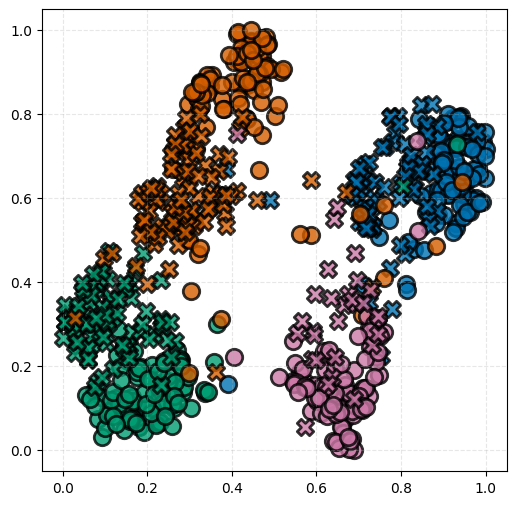

In [ ]:
import ipywidgets as widgets
from IPython.display import display

save_checkbox = widgets.Checkbox(
    value=False,
    description="Save Figures",
    indent=False
)

ui = widgets.VBox([
    widgets.IntSlider(
        min=5, max=200, step=5, value=50,
        description="Neighbors"
    ),
    widgets.FloatSlider(
        min=0.0, max=1, step=0.05, value=0.15,
        description="Min dist"
    ),
    save_checkbox
])

out = widgets.interactive_output(
    interactive_plot,
    {
        "n_neighbors": ui.children[0],
        "min_dist": ui.children[1],
        "save_figures": ui.children[2],  # pass checkbox value
    }
)

display(ui, out)
